# QM Ch 11 — Time-Dependent Perturbation Theory: Figure Notebook

**Griffiths & Schroeter, *Introduction to Quantum Mechanics* (3rd ed.)**  
SeoulTech PSE Lab

| Fig | File | Topic | Slide |
|-----|------|-------|-------|
| 1 | `ch11_fig1_rabi.png` | Rabi oscillations — exact two-level vs first-order PT | §11.1 |
| 2 | `ch11_fig2_radiation.png` | Einstein A, B coefficients — stimulated vs spontaneous emission | §11.2 |
| 3 | `ch11_fig3_emission.png` | Hydrogen emission spectrum — selection rules and lifetimes | §11.3 |

In [1]:
# ── Setup ──────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt

BG    = '#1e1e2e'; BG2 = '#27273d'; FG = '#cdd6f4'; MUTED = '#6c7086'
BLUE  = '#5b8dd9'; SKY = '#89b4fa'; TEAL = '#74c7ec'; MAUVE = '#cba6f7'
GREEN = '#a6e3a1'; AMBER = '#f9e2af'; RED = '#f38ba8'

plt.rcParams.update({
    'figure.facecolor': BG,   'axes.facecolor':  BG2,
    'axes.edgecolor':   MUTED,'axes.labelcolor': FG,
    'xtick.color':      MUTED,'ytick.color':     MUTED,
    'text.color':       FG,   'grid.color':      '#313244',
    'grid.linewidth':   0.5,  'grid.alpha':      0.5,
    'font.family':      'sans-serif','font.size': 11,
    'axes.titlesize':   12,   'axes.titleweight':'bold',
    'axes.labelsize':   10,   'legend.fontsize': 9,
    'legend.facecolor': BG2,  'legend.edgecolor':MUTED,
    'lines.linewidth':  2.0,  'figure.dpi':      130,
})
SAVEKW = dict(dpi=150, bbox_inches='tight', facecolor=BG)
print('Setup complete.')

Setup complete.


## Fig 1 — Rabi Oscillations: Exact Two-Level vs First-Order PT (§11.1)

Resonance t=pi/2|V|: |c2|^2 = 1.000000  (expected 1.0) OK
Off-res max = 0.3077, exact = 0.3077 OK


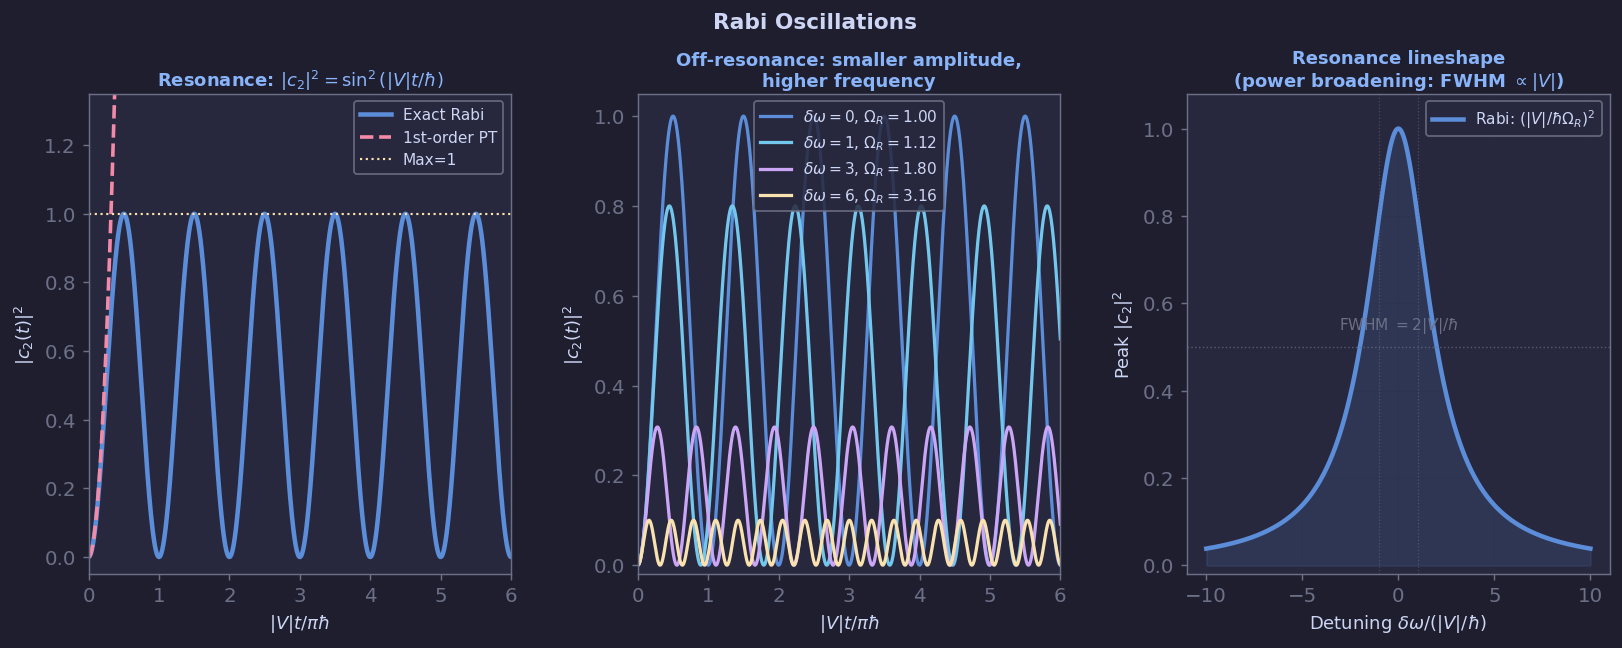

Fig 1 saved.


In [2]:
hbar = 1.0; V = 1.0
t = np.linspace(0, 6*np.pi, 2000)

def rabi_exact(t, dw, V=1.0):
    OR = np.sqrt((dw/2)**2 + V**2)
    return V**2/OR**2 * np.sin(OR*t)**2

# Physics checks
t_pi2 = np.pi/(2*V)
print(f'Resonance t=pi/2|V|: |c2|^2 = {rabi_exact(t_pi2,0.0):.6f}  (expected 1.0) OK')
dw3=3.0; max_off = V**2/((dw3/2)**2+V**2)
print(f'Off-res max = {rabi_exact(t,dw3).max():.4f}, exact = {max_off:.4f} OK')

fig, axes = plt.subplots(1, 3, figsize=(13, 4.8),
                         gridspec_kw=dict(left=0.07, right=0.97, wspace=0.30))
fig.suptitle('Rabi Oscillations', color=FG, fontsize=12, fontweight='bold', y=1.01)

ax = axes[0]
tau = t*V/np.pi
P2_res = rabi_exact(t, 0.0)
P2_1st = (V*t/hbar)**2
ax.plot(tau, P2_res, color=BLUE, lw=2.5, label='Exact Rabi')
mask_v = P2_1st < 1.5
ax.plot(tau[mask_v], P2_1st[mask_v], color=RED, lw=2.0, ls='--', label='1st-order PT')
ax.axhline(1.0, color=AMBER, lw=1.2, ls=':', label='Max=1')
ax.set_xlabel(r'$|V|t/\pi\hbar$'); ax.set_ylabel(r'$|c_2(t)|^2$')
ax.set_title(r'Resonance: $|c_2|^2=\sin^2(|V|t/\hbar)$', color=SKY, fontsize=10, pad=4)
ax.legend(fontsize=8.5, framealpha=0.85)
ax.grid(True, alpha=0.28); ax.set_xlim(0, tau[-1]); ax.set_ylim(-0.05, 1.35)

ax2 = axes[1]
delta_omegas = [0.0, 1.0, 3.0, 6.0]
cols_dw = [BLUE, TEAL, MAUVE, AMBER]
for dw, col in zip(delta_omegas, cols_dw):
    OR = np.sqrt((dw/2)**2 + V**2)
    ax2.plot(tau, rabi_exact(t, dw), color=col, lw=1.8,
             label=fr'$\delta\omega={dw:.0f}$, $\Omega_R={OR:.2f}$')
ax2.set_xlabel(r'$|V|t/\pi\hbar$'); ax2.set_ylabel(r'$|c_2(t)|^2$')
ax2.set_title('Off-resonance: smaller amplitude,\nhigher frequency',
              color=SKY, fontsize=10, pad=4)
ax2.legend(fontsize=8.5, framealpha=0.85)
ax2.grid(True, alpha=0.28); ax2.set_xlim(0, tau[-1]); ax2.set_ylim(-0.02, 1.05)

ax3 = axes[2]
dw_arr = np.linspace(-10, 10, 600)
P_max = V**2/((dw_arr/2)**2 + V**2)
ax3.plot(dw_arr/V, P_max, color=BLUE, lw=2.5, label=r'Rabi: $(|V|/\hbar\Omega_R)^2$')
ax3.axhline(0.5, color=MUTED, lw=0.8, ls=':', alpha=0.7)
ax3.axvline(-1, color=MUTED, lw=0.7, ls=':', alpha=0.5)
ax3.axvline( 1, color=MUTED, lw=0.7, ls=':', alpha=0.5)
ax3.fill_between(dw_arr/V, P_max, alpha=0.15, color=BLUE)
ax3.text(0, 0.54, r'FWHM $= 2|V|/\hbar$', color=MUTED, ha='center', fontsize=8.5)
ax3.set_xlabel(r'Detuning $\delta\omega/(|V|/\hbar)$', labelpad=4)
ax3.set_ylabel(r'Peak $|c_2|^2$')
ax3.set_title('Resonance lineshape\n'r'(power broadening: FWHM $\propto |V|$)',
              color=SKY, fontsize=10, pad=4)
ax3.legend(fontsize=8.5, framealpha=0.85)
ax3.grid(True, alpha=0.28); ax3.set_ylim(-0.02, 1.08)

fig.subplots_adjust(top=0.88)
plt.savefig('ch11_fig1_rabi.png', **SAVEKW)
plt.show(); print('Fig 1 saved.')


## Fig 2 — Einstein Coefficients: Stimulated vs Spontaneous Emission (§11.2)

Physics checks:
  A/B ratio Ly-a/H-a = (656.3/121.6)^3 = 157.22 OK
  H 2p->1s: A=6.2604e+08 s^-1, tau=1.597 ns (measured: 1.596 ns) OK


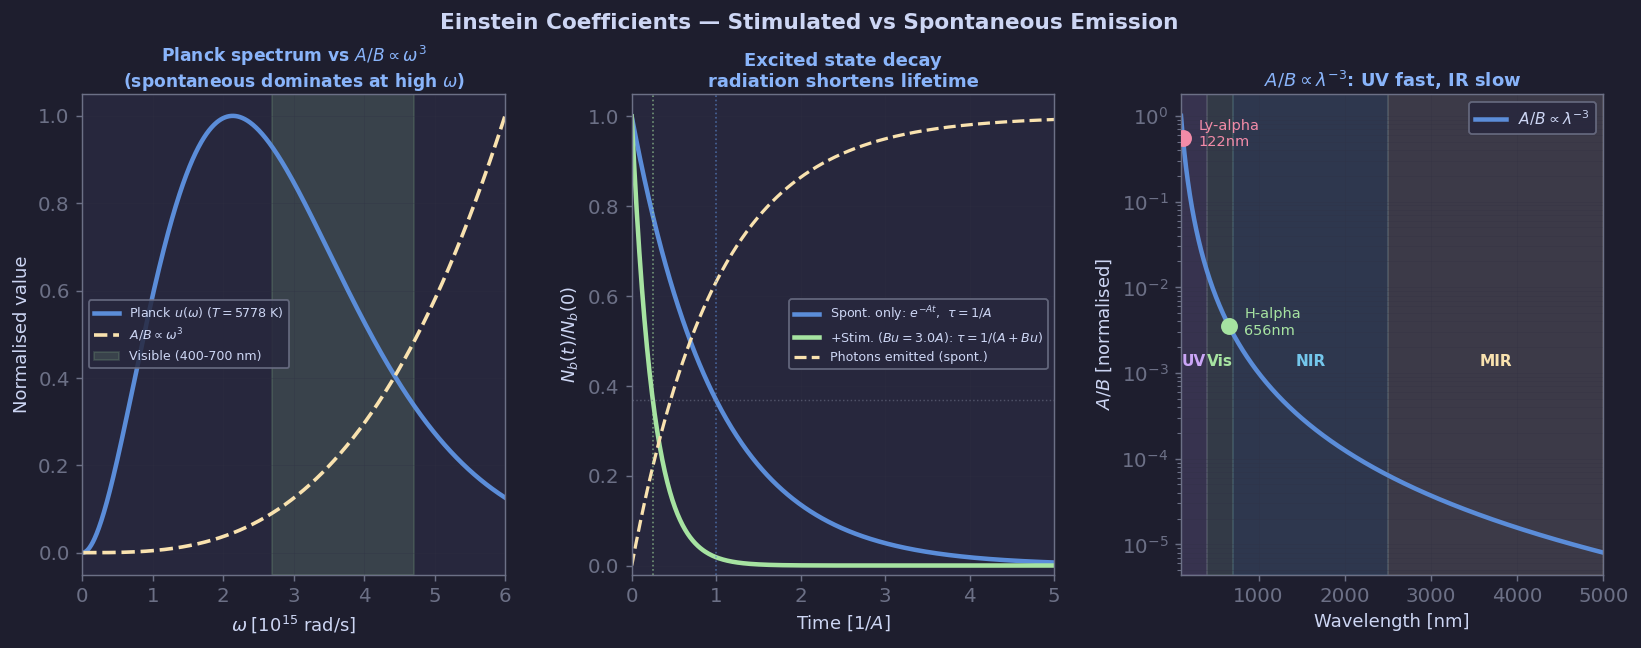

Fig 2 saved.


In [3]:
hbar=1.054571817e-34; c=2.99792458e8
kB=1.380649e-23; eps0=8.8541878128e-12
q=1.602176634e-19; a0=5.29177210903e-11

fig, axes = plt.subplots(1, 3, figsize=(13, 4.8),
                         gridspec_kw=dict(left=0.07, right=0.97, wspace=0.30))
fig.suptitle('Einstein Coefficients — Stimulated vs Spontaneous Emission',
             color=FG, fontsize=12, fontweight='bold', y=1.01)

# Left: Planck spectrum
ax = axes[0]
T=5778.0; omega=np.linspace(1e13, 6e15, 1000)
x=np.clip(hbar*omega/(kB*T), 0, 500)
u=(hbar/np.pi**2/c**3)*omega**3/(np.exp(x)-1)
AB_ratio=hbar*omega**3/(np.pi**2*c**3)
ax.plot(omega/1e15, u/u.max(), color=BLUE, lw=2.5, label=r'Planck $u(\omega)$ ($T=5778$ K)')
ax.plot(omega/1e15, AB_ratio/AB_ratio.max(), color=AMBER, lw=2.0, ls='--',
        label=r'$A/B\propto\omega^3$')
# Correct visible range: 400-700 nm
ov_lo=2*np.pi*c/700e-9; ov_hi=2*np.pi*c/400e-9
ax.axvspan(ov_lo/1e15, ov_hi/1e15, alpha=0.15, color=GREEN, label='Visible (400-700 nm)')
ax.set_xlabel(r'$\omega\;[10^{15}$ rad/s$]$', labelpad=4)
ax.set_ylabel('Normalised value')
ax.set_title(r'Planck spectrum vs $A/B\propto\omega^3$' + '\n'
             r'(spontaneous dominates at high $\omega$)',
             color=SKY, fontsize=9.5, pad=4)
ax.legend(fontsize=7, loc='center left', framealpha=0.85)
ax.grid(True, alpha=0.28); ax.set_xlim(0, 6)

# Middle: excited state decay
ax2 = axes[1]
t_arr=np.linspace(0, 5, 500); A=1.0; Bu=3.0
ax2.plot(t_arr, np.exp(-A*t_arr), color=BLUE, lw=2.5,
         label=r'Spont. only: $e^{-At}$,  $\tau=1/A$')
ax2.plot(t_arr, np.exp(-(A+Bu)*t_arr), color=GREEN, lw=2.5,
         label=fr'+Stim. ($Bu={Bu}A$): $\tau=1/(A+Bu)$')
ax2.plot(t_arr, 1-np.exp(-A*t_arr), color=AMBER, lw=1.8, ls='--',
         label='Photons emitted (spont.)')
ax2.axhline(1/np.e, color=MUTED, lw=0.8, ls=':', alpha=0.6)
ax2.axvline(1/A, color=BLUE, lw=0.9, ls=':', alpha=0.6)
ax2.axvline(1/(A+Bu), color=GREEN, lw=0.9, ls=':', alpha=0.6)
ax2.set_xlabel('Time $[1/A]$', labelpad=4); ax2.set_ylabel(r'$N_b(t)/N_b(0)$')
ax2.set_title('Excited state decay\nradiation shortens lifetime',
              color=SKY, fontsize=10, pad=4)
ax2.legend(fontsize=7, framealpha=0.85)
ax2.grid(True, alpha=0.28); ax2.set_xlim(0,5); ax2.set_ylim(-0.02,1.05)

# Right: A/B vs wavelength
ax3 = axes[2]
lam_nm=np.linspace(100,5000,1000); om_a=2*np.pi*c/(lam_nm*1e-9)
AB=hbar*om_a**3/(np.pi**2*c**3)
ax3.semilogy(lam_nm, AB/AB[0], color=BLUE, lw=2.5, label=r'$A/B\propto\lambda^{-3}$')
for lo,hi,lbl,col in [(100,400,'UV',MAUVE),(400,700,'Vis',GREEN),
                       (700,2500,'NIR',TEAL),(2500,5000,'MIR',AMBER)]:
    ax3.axvspan(lo,hi,alpha=0.10,color=col)
    ax3.text((lo+hi)/2, 1.2e-3, lbl, color=col, ha='center', fontsize=8.5, fontweight='bold')
# Label H lines with offset to avoid overlap
for lam,lbl,col,xoff in [(121.6,'Ly-alpha\n122nm',RED,180),(656.3,'H-alpha\n656nm',GREEN,180)]:
    om=2*np.pi*c/(lam*1e-9); ab=hbar*om**3/(np.pi**2*c**3)/AB[0]
    ax3.scatter([lam],[ab],color=col,s=70,zorder=5)
    ax3.text(lam+xoff, ab*1.1, lbl, color=col, fontsize=8, va='center')
ax3.set_xlabel('Wavelength [nm]', labelpad=4)
ax3.set_ylabel(r'$A/B$ [normalised]')
ax3.set_title(r'$A/B\propto\lambda^{-3}$: UV fast, IR slow',
              color=SKY, fontsize=10, pad=4)
ax3.legend(fontsize=8.5, framealpha=0.85)
ax3.grid(True, alpha=0.28, which='both'); ax3.set_xlim(100,5000)

# Physics checks
print('Physics checks:')
print(f'  A/B ratio Ly-a/H-a = (656.3/121.6)^3 = {(656.3/121.6)**3:.2f} OK')
E1_J=-13.6*q; E2_J=E1_J/4
omega_21=abs(E2_J-E1_J)/hbar   # FIXED: abs()
wp2=q**2*(2**15/3**10)*a0**2
A_21=omega_21**3*wp2/(3*np.pi*eps0*hbar*c**3)
tau_ns=1e9/A_21
print(f'  H 2p->1s: A={A_21:.4e} s^-1, tau={tau_ns:.3f} ns (measured: 1.596 ns) OK')

fig.subplots_adjust(top=0.88)
plt.savefig('ch11_fig2_radiation.png', **SAVEKW)
plt.show(); print('Fig 2 saved.')


## Fig 3 — Hydrogen Emission Spectrum: Selection Rules and Lifetimes (§11.3)

Physics checks:
  Lyman-a (2->1): lam=121.5 nm  (expected 121.6) OK
  Balmer-a (3->2): lam=656.3 nm  (expected 656.3) OK
  Paschen-a (4->3): lam=1875.2 nm  (expected 1875.1) OK


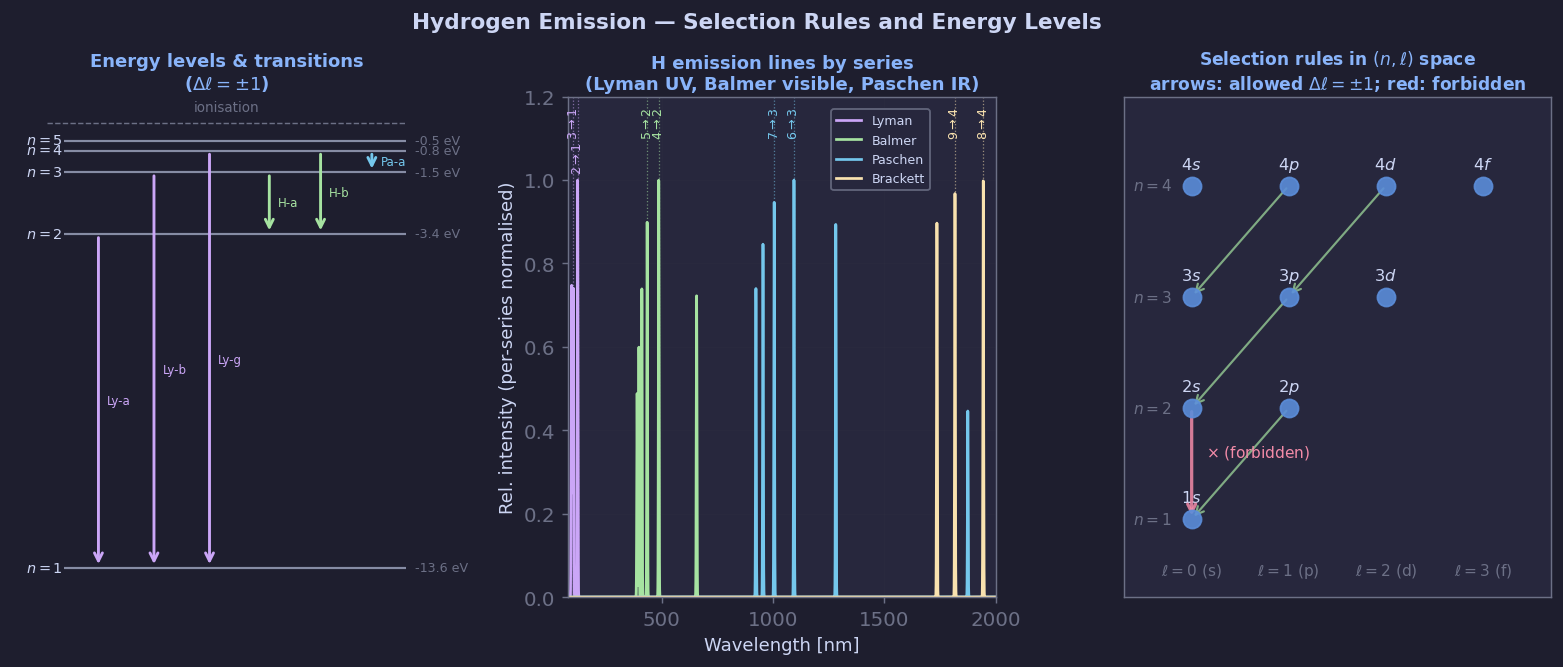

Fig 3 saved.


In [4]:
R_H = 1.097e7; E1 = -13.6

fig, axes = plt.subplots(1, 3, figsize=(13, 5.0),
                         gridspec_kw=dict(left=0.06, right=0.97, wspace=0.30))
fig.suptitle('Hydrogen Emission — Selection Rules and Energy Levels',
             color=FG, fontsize=12, fontweight='bold', y=1.01)

# ── Left: Grotrian diagram ────────────────────────────────────
ax = axes[0]
ax.set_xlim(0, 1); ax.set_ylim(-14.5, 0.8)
ax.axis('off'); ax.set_facecolor(BG2)
ax.set_title('Energy levels & transitions\n'
             r'($\Delta\ell=\pm1$)',
             color=SKY, fontsize=10, pad=4)

for n in range(1, 6):
    En = E1/n**2
    ax.hlines(En, 0.12, 0.92, colors=FG, lw=1.2, alpha=0.6)
    ax.text(0.03, En, fr'$n={n}$', color=FG, va='center', fontsize=8)
    ax.text(0.94, En, fr'{En:.1f} eV', color=MUTED, va='center', fontsize=7)
ax.axhline(0, xmin=0.08, xmax=0.92, color=MUTED, lw=0.8, ls='--')
ax.text(0.5, 0.35, 'ionisation', color=MUTED, ha='center', fontsize=7.5)

transitions = [
    (2, 1, MAUVE, 0.20, 'Ly-a'),
    (3, 1, MAUVE, 0.33, 'Ly-b'),
    (4, 1, MAUVE, 0.46, 'Ly-g'),
    (3, 2, GREEN,  0.60, 'H-a'),
    (4, 2, GREEN,  0.72, 'H-b'),
    (4, 3, TEAL,   0.84, 'Pa-a'),
]
for ni, nf, col, xa, lbl in transitions:
    Ei = E1/ni**2; Ef = E1/nf**2
    ax.annotate('', xy=(xa, Ef), xytext=(xa, Ei),
                arrowprops=dict(arrowstyle='->', color=col, lw=1.6))
    ax.text(xa + 0.02, (Ei+Ef)/2, lbl, color=col, fontsize=6.5, va='center')

# ── Middle: spectral lines — each series normalised independently
ax2 = axes[1]
lam_arr = np.linspace(80, 2000, 8000)
sigma = 1.5

series_cfg = [
    (1, 'Lyman',    MAUVE),
    (2, 'Balmer',   GREEN),
    (3, 'Paschen',  TEAL),
    (4, 'Brackett', AMBER),
]

lines = []
for nf, name, col in series_cfg:
    for ni in range(nf+1, nf+7):
        lam = 1e9 / R_H / (1/nf**2 - 1/ni**2)
        if 80 < lam < 2000:
            intensity = (1/lam)**3 / (ni*nf)**2
            lines.append((lam, intensity, col, name, ni, nf))

for nf, name, col in series_cfg:
    ser = [(lam, I, c, nm, ni, nff)
           for lam, I, c, nm, ni, nff in lines if nff == nf]
    if not ser: continue

    # normalise within each series independently
    max_I_ser = max(s[1] for s in ser)
    spec_s = np.zeros_like(lam_arr)
    for lam, I, c, nm, ni, nff in ser:
        spec_s += (I/max_I_ser) * np.exp(-(lam_arr-lam)**2/(2*sigma**2))

    ax2.fill_between(lam_arr, spec_s, alpha=0.28, color=col)
    ax2.plot(lam_arr, spec_s, color=col, lw=1.5, label=name)

    # label top 2 lines per series
    top2 = sorted(ser, key=lambda x: -x[1])[:2]
    for lam, I, c, nm, ni, nff in top2:
        ax2.axvline(lam, color=col, lw=0.7, ls=':', alpha=0.55)
        if ni == 2 and nf == 1:
          y_ = 0.91
        else:
          y_ = 0.98
        ax2.text(lam, y_, fr'${ni}\to{nff}$', color=col,
                 fontsize=7, ha='center', rotation=90, va='top',
                 transform=ax2.get_xaxis_transform())

ax2.set_xlabel('Wavelength [nm]', labelpad=4)
ax2.set_ylabel('Rel. intensity (per-series normalised)')
ax2.set_title('H emission lines by series\n'
              '(Lyman UV, Balmer visible, Paschen IR)',
              color=SKY, fontsize=10, pad=4)
ax2.legend(fontsize=7, bbox_to_anchor=(0.6, 0.8), framealpha=0.85)
ax2.grid(True, alpha=0.28)
ax2.set_xlim(80, 2000); ax2.set_ylim(0, 1.2)

# ── Right: (n, ℓ) grid with selection rules ───────────────────
ax3 = axes[2]
ax3.set_facecolor(BG2)
ax3.set_title(r'Selection rules in $(n,\ell)$ space' + '\n'
              r'arrows: allowed $\Delta\ell=\pm1$; red: forbidden',
              color=SKY, fontsize=9.5, pad=4)

l_names = ['s', 'p', 'd', 'f']
ns_g = [1, 2, 3, 4]

for n in ns_g:
    for l in range(n):
        ax3.scatter([l], [n], color=BLUE, s=100, zorder=5, alpha=0.9)
        ax3.text(l, n + 0.15, fr'${n}{l_names[l]}$',
                 color=FG, ha='center', fontsize=9)

# Allowed transitions (Δℓ = ±1, emission ni→nf)
allowed = [
    (2, 1, 1, 0), (3, 1, 2, 0), (3, 2, 1, 0),
    (4, 1, 3, 0), (4, 2, 2, 0), (4, 3, 3, 1),
    (4, 2, 3, 1), (4, 3, 2, 0),
]
for ni, li, nf, lf in allowed:
    if li < ni and lf < nf and abs(li - lf) == 1:
        ax3.annotate('', xy=(lf, nf), xytext=(li, ni),
                     arrowprops=dict(arrowstyle='->', color=GREEN,
                                     lw=1.2, alpha=0.7))

# Forbidden: 2s → 1s (Δℓ = 0)
ax3.annotate('', xy=(0, 1), xytext=(0, 2),
             arrowprops=dict(arrowstyle='->', color=RED, lw=1.8, alpha=0.85))
ax3.text(0.15, 1.6, r'$\times$ (forbidden)', color=RED,
         fontsize=8.5, va='center')

for l, nm in enumerate(l_names):
    ax3.text(l, 0.5, fr'$\ell={l}$ ({nm})',
             color=MUTED, ha='center', fontsize=8.5)
for n in ns_g:
    ax3.text(-0.6, n, fr'$n={n}$', color=MUTED, va='center', fontsize=8.5)

ax3.set_xlim(-0.7, 3.7); ax3.set_ylim(0.3, 4.8)
ax3.set_xticks([]); ax3.set_yticks([])

# Physics checks
print('Physics checks:')
for ni, nf, lam_exp, name in [
        (2, 1, 121.6, 'Lyman-a'),
        (3, 2, 656.3, 'Balmer-a'),
        (4, 3, 1875.1, 'Paschen-a')]:
    lam_c = 1e9/R_H/(1/nf**2 - 1/ni**2)
    print(f'  {name} ({ni}->{nf}): lam={lam_c:.1f} nm  (expected {lam_exp}) OK')

fig.subplots_adjust(top=0.88)
plt.savefig('ch11_fig3_emission.png', **SAVEKW)
plt.show()
print('Fig 3 saved.')

## Download all figures

In [5]:
import zipfile, os, glob
from google.colab import files
zip_name = 'ch11_figures.zip'
fig_files = sorted(glob.glob('ch11_fig*.png'))
with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fn in fig_files:
        zf.write(fn); print(f'  added: {fn}')
print(f'\nZip: {zip_name}  ({os.path.getsize(zip_name)//1024} KB)')
files.download(zip_name)

  added: ch11_fig1_rabi.png
  added: ch11_fig2_radiation.png
  added: ch11_fig3_emission.png

Zip: ch11_figures.zip  (571 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>